In [ ]:
# Assessment 4 - Part 2: EDA and Visualisation
# Minh Nguyet Tran - s394122

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import chi2_contingency, mannwhitneyu
from IPython.display import display

# Set display options for better readability
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# Function to display a summary table of the DataFrame's columns, including non-null counts and data types
def show_column_summary(df, name):
    tbl = pd.DataFrame({
        "#": range(len(df.columns)),
        "Column": df.columns,
        "Non-Null Count": [f"{df[c].notna().sum()} non-null" for c in df.columns],
        "Dtype": [str(df[c].dtype) for c in df.columns]
    })
    print(f"\n{name} ({len(df.columns)} columns):")
    display(tbl)


# Function to interpret Cramer's V value into qualitative strength categories
def interpret_cramers_v(v):
    if pd.isna(v):
        return "n/a"
    if v < 0.10:
        return "very weak"
    if v < 0.20:
        return "weak-moderate"
    if v < 0.30:
        return "moderate"
    return "strong"

# Function to perform chi-squared test and calculate Cramer's V for a given contingency table
def cramers_v_test(ct):
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    k = min(ct.shape[0] - 1, ct.shape[1] - 1)
    cv = np.nan if k == 0 else np.sqrt(chi2 / (n * k))
    return chi2, p, dof, n, cv

# Function to create a summary table of chi-squared test results and Cramer's V for specified features against a target variable
def chi_cramers_table(df, features, target):
    rows = []
    for feat in features:
        ct = pd.crosstab(df[feat], df[target])
        chi2, p, dof, n, cv = cramers_v_test(ct)
        rows.append({
            "feature": feat,
            "target": target,
            "chi2": round(chi2, 2),
            "p_value": round(p, 4),
            "df": dof,
            "n": int(n),
            "cramers_v": round(cv, 4),
            "strength": interpret_cramers_v(cv)
        })
    return pd.DataFrame(rows).sort_values("cramers_v", ascending=False).reset_index(drop=True)


In [2]:
BASE_DIR = Path(r"C:\Users\ASUS\Downloads")
DATA_DIR = BASE_DIR / "outputs_prt564_part1_v2" / "cleaned_data"
OUTPUT_DIR = BASE_DIR / "outputs_prt564_part2_eda" / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RQ1_FILE = DATA_DIR / "rq1_qualification_relevance_part1_dataset_v2.csv"
RQ2_FILE = DATA_DIR / "rq2_migrant_income_part1_dataset_v2.csv"


In [3]:
rq1 = pd.read_csv(RQ1_FILE)
rq2 = pd.read_csv(RQ2_FILE)

print("rq1:", rq1.shape, "  rq2:", rq2.shape)

show_column_summary(rq1, "RQ1")
show_column_summary(rq2, "RQ2")

# missing + dupes
for name, df in [("RQ1", rq1), ("RQ2", rq2)]:
    miss = df.isna().sum().reset_index()
    miss.columns = ["column", "missing"]
    print(f"\n{name} missing values:")
    display(miss)
    print(f"{name} duplicates: {df.duplicated().sum()}")


rq1: (9946, 18)   rq2: (284, 7)

RQ1 (18 columns):


,#,Column,Non-Null Count,Dtype
0,0,employment_status,9946 non-null,str
1,1,sex,9946 non-null,str
2,2,age_group,9946 non-null,str
3,3,target,9946 non-null,str
4,4,age_midpoint,9946 non-null,float64
5,5,number_of_non_school_qualifications,9946 non-null,str
6,6,qualification_recency,9946 non-null,str
7,7,current_job_skill_level,9946 non-null,str
8,8,country_of_birth_group,9946 non-null,str
9,9,citizenship_status,9946 non-null,str



RQ2 (7 columns):


,#,Column,Non-Null Count,Dtype
0,0,visa_group,284 non-null,str
1,1,age_range,284 non-null,str
2,2,applicant_status,284 non-null,str
3,3,sex,284 non-null,str
4,4,arrival_group,284 non-null,str
5,5,age_midpoint,284 non-null,float64
6,6,income_target,284 non-null,str



RQ1 missing values:


,column,missing
0,employment_status,0
1,sex,0
2,age_group,0
3,target,0
4,age_midpoint,0
5,number_of_non_school_qualifications,0
6,qualification_recency,0
7,current_job_skill_level,0
8,country_of_birth_group,0
9,citizenship_status,0


RQ1 duplicates: 5001

RQ2 missing values:


,column,missing
0,visa_group,0
1,age_range,0
2,applicant_status,0
3,sex,0
4,arrival_group,0
5,age_midpoint,0
6,income_target,0


RQ2 duplicates: 0


,target,count
0,Relevant,8287
1,Not relevant,1659


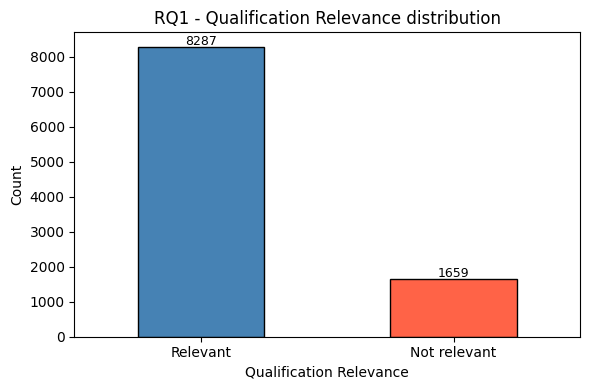


RQ1 chi-square / Cramer's V:


,feature,target,chi2,p_value,df,n,cramers_v,strength
0,current_job_skill_level,target,1458.46,0.0000,4,9946,0.3829,strong
1,occupation,target,1424.09,0.0000,7,9946,0.3784,strong
2,occupation_income_level,target,459.51,0.0000,1,9946,0.2149,moderate
3,employment_status,target,157.67,0.0000,1,9946,0.1259,weak–moderate
4,age_group,target,81.12,0.0000,5,9946,0.0903,very weak
5,citizenship_status,target,72.58,0.0000,1,9946,0.0854,very weak
6,number_of_non_school_qualifications,target,37.94,0.0000,2,9946,0.0618,very weak
7,country_of_birth_group,target,24.32,0.0000,1,9946,0.0495,very weak
8,qualification_recency,target,12.18,0.0005,1,9946,0.0350,very weak
9,sex,target,0.69,0.4048,1,9946,0.0084,very weak



employment_status: chi2=157.67, p=0.0, V=0.1259


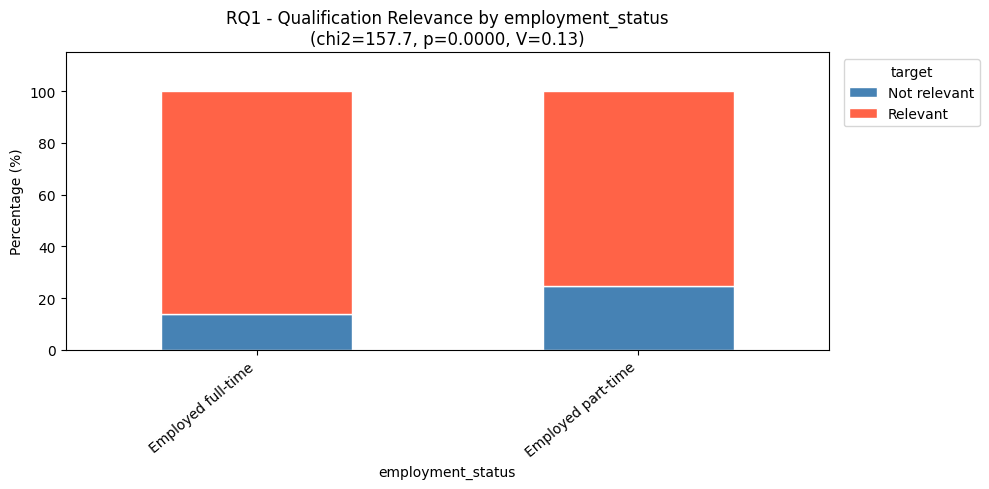


sex: chi2=0.69, p=0.4048, V=0.0084


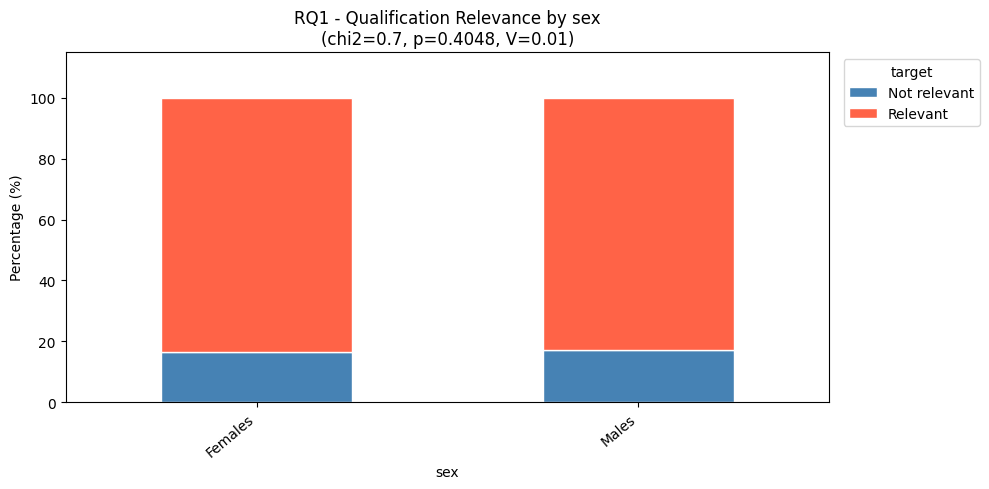


age_group: chi2=81.12, p=0.0, V=0.0903


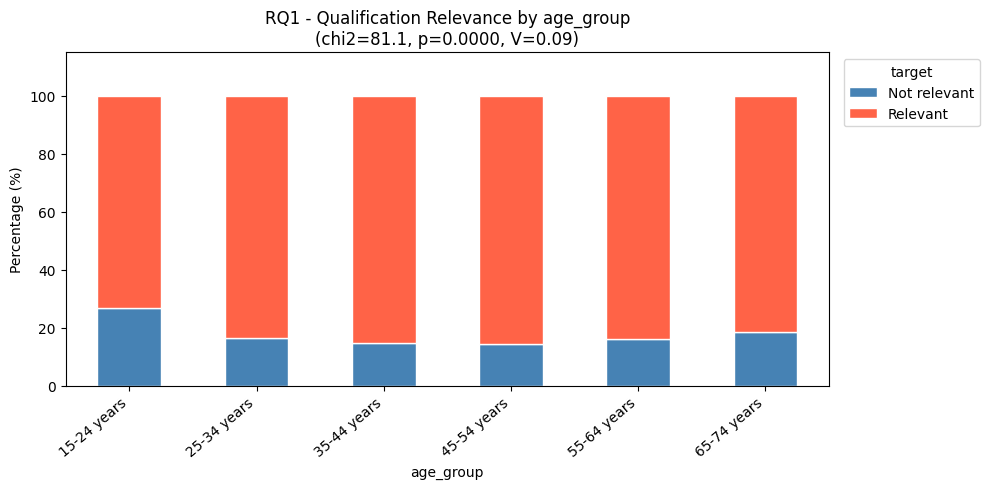


number_of_non_school_qualifications: chi2=37.94, p=0.0, V=0.0618


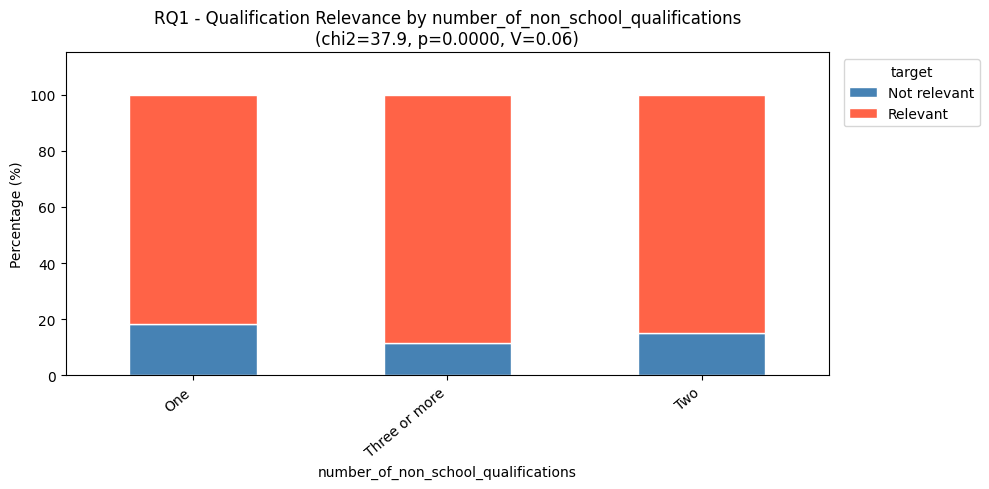


qualification_recency: chi2=12.18, p=0.0005, V=0.035


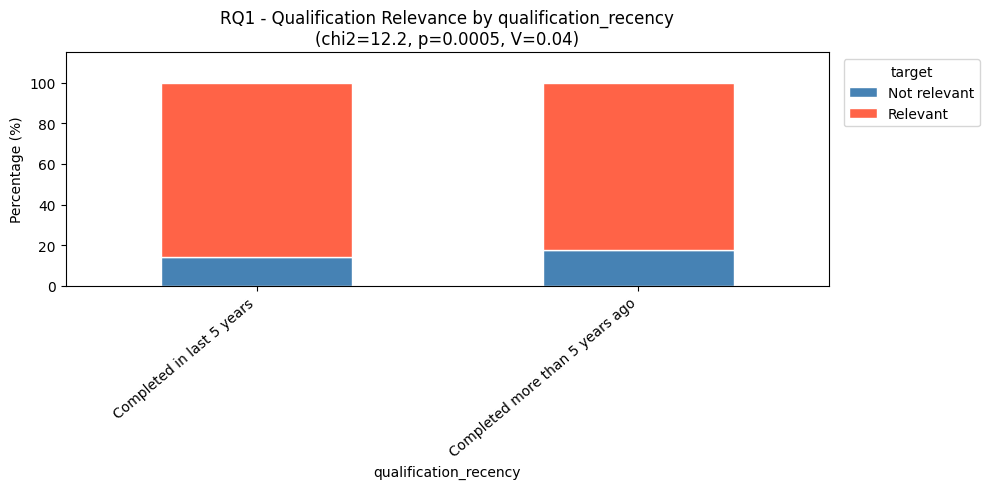


current_job_skill_level: chi2=1458.46, p=0.0, V=0.3829


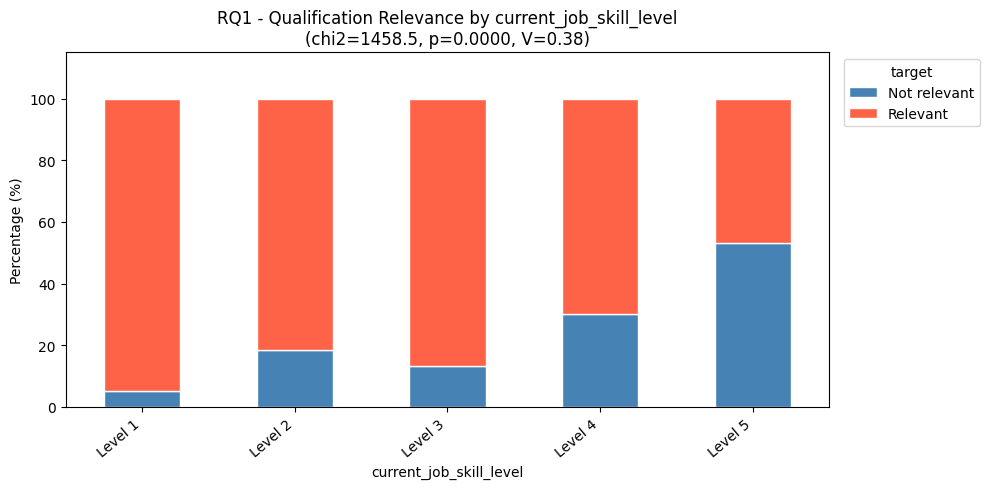


country_of_birth_group: chi2=24.32, p=0.0, V=0.0495


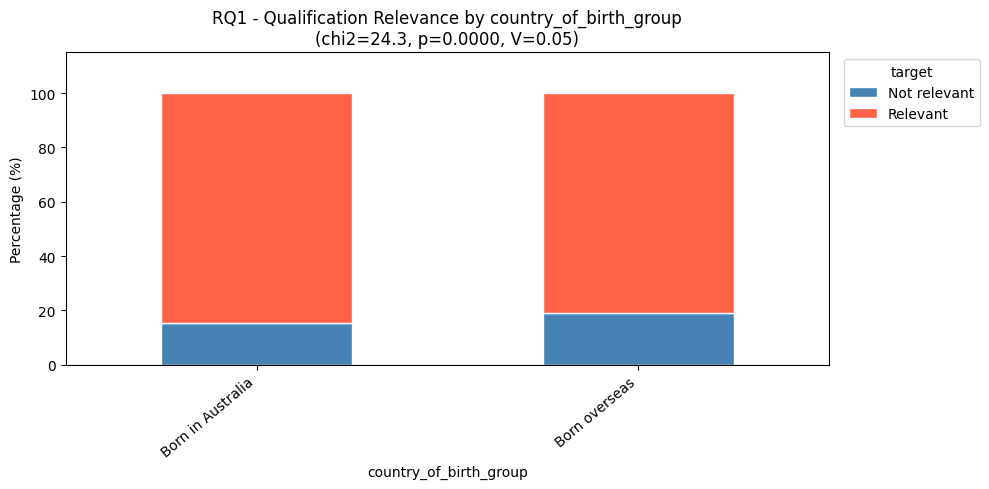


citizenship_status: chi2=72.58, p=0.0, V=0.0854


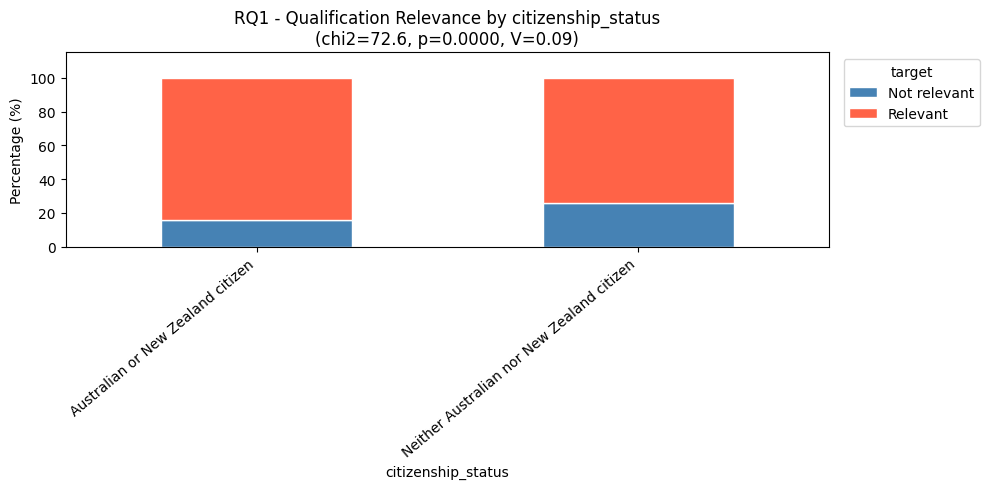


occupation: chi2=1424.09, p=0.0, V=0.3784


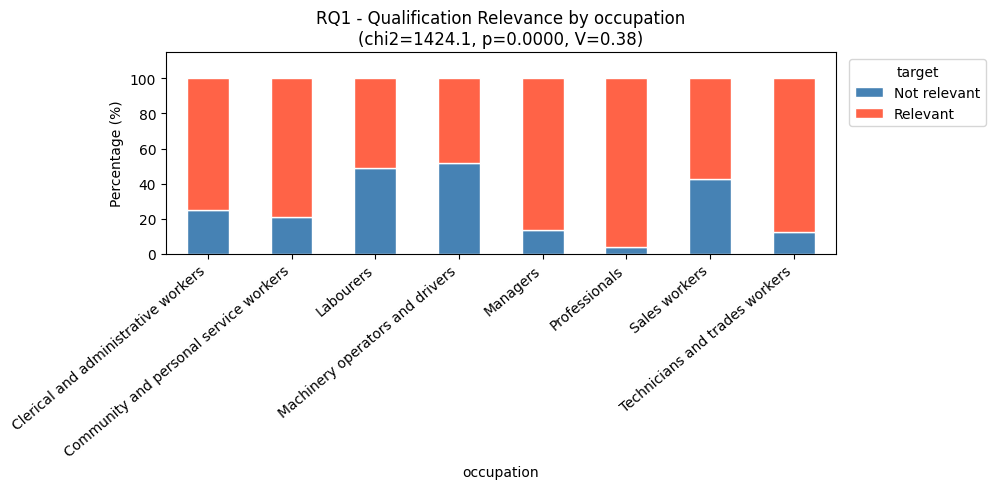


occupation_income_level: chi2=459.51, p=0.0, V=0.2149


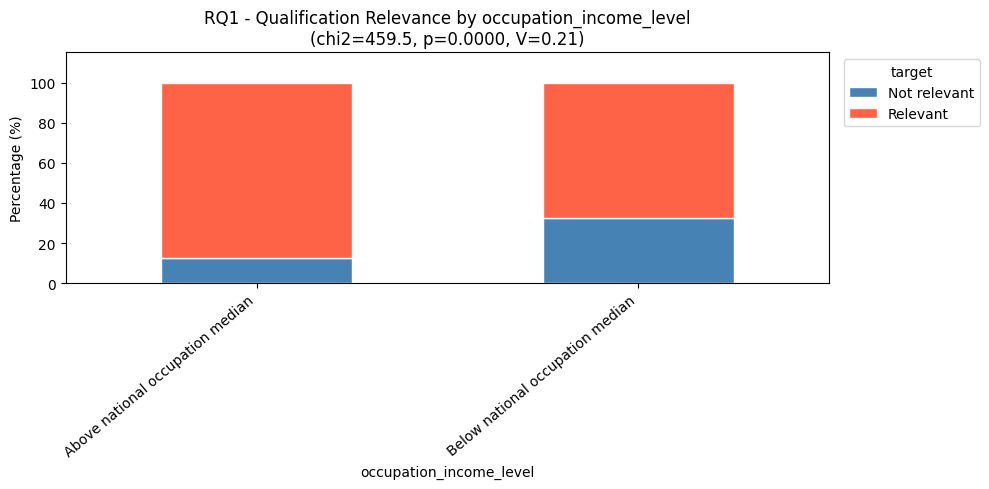

In [4]:
# Research Question 1: Qualification Relevance
# Analyze the distribution of the target variable and its relationship with categorical features using chi-squared tests and Cramer's V.
counts = rq1["target"].value_counts()
display(counts.rename_axis("target").reset_index(name="count"))
# Visualize the distribution of the target variable
plt.figure(figsize=(6, 4))
counts.plot(kind="bar", color=["steelblue", "tomato"], edgecolor="black")
plt.title("RQ1 - Qualification Relevance distribution")
plt.xlabel("Qualification Relevance")
plt.ylabel("Count")
plt.xticks(rotation=0)
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rq1_target_distribution.png", dpi=150)
plt.show()

rq1_cat = [
    "employment_status", "sex", "age_group",
    "number_of_non_school_qualifications", "qualification_recency",
    "current_job_skill_level", "country_of_birth_group",
    "citizenship_status", "occupation", "occupation_income_level",
]

rq1_chi = chi_cramers_table(rq1, rq1_cat, "target")
print("\nRQ1 chi-square / Cramer's V:")
display(rq1_chi)
rq1_chi.to_csv(OUTPUT_DIR / "rq1_chi_square_cramers_v_results.csv", index=False)

for feat in rq1_cat:
    ct_pct = pd.crosstab(rq1[feat], rq1["target"])
    ct_pct = ct_pct.div(ct_pct.sum(axis=1), axis=0) * 100

    r = rq1_chi.loc[rq1_chi["feature"] == feat].iloc[0]
    print(f"\n{feat}: chi2={r.chi2}, p={r.p_value}, V={r.cramers_v}")

    ct_pct.plot(kind="bar", stacked=True, figsize=(10, 5),
                color=["steelblue", "tomato"], edgecolor="white")
    plt.title(f"RQ1 - Qualification Relevance by {feat}\n(chi2={r.chi2:.1f}, p={r.p_value:.4f}, V={r.cramers_v:.2f})")
    plt.xlabel(feat)
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=40, ha="right")
    plt.ylim(0, 115)
    plt.legend(title="target", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"rq1_{feat}_stacked.png", dpi=150)
    plt.show()


age_midpoint  U=7363266, p=0.0000


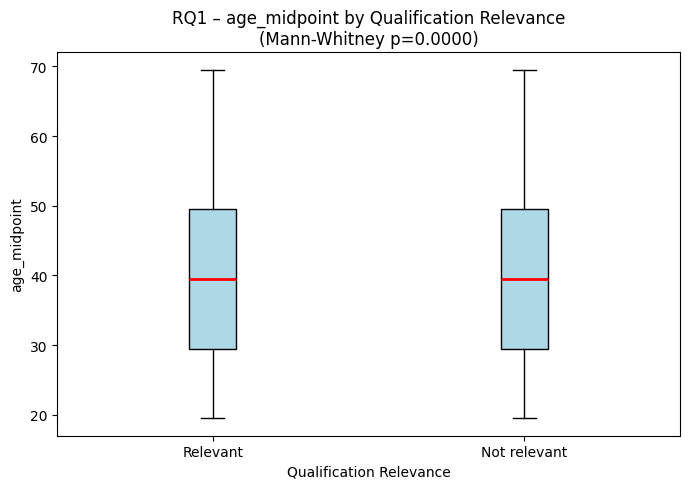

occupation_median_income_2022_23  U=10131992, p=0.0000


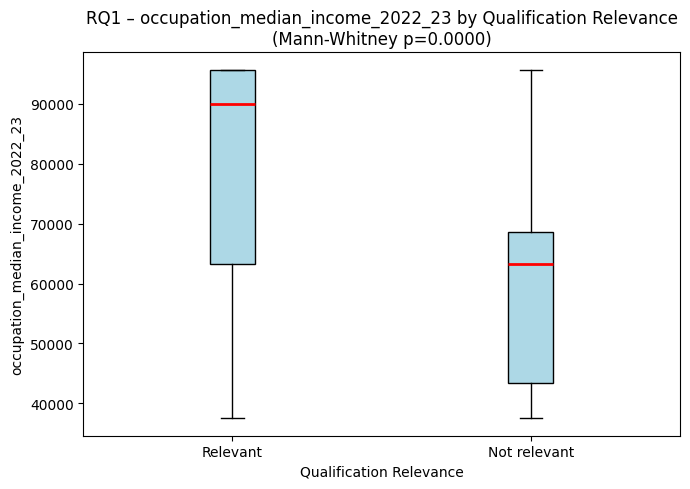

occupation_income_rank  U=3616141, p=0.0000


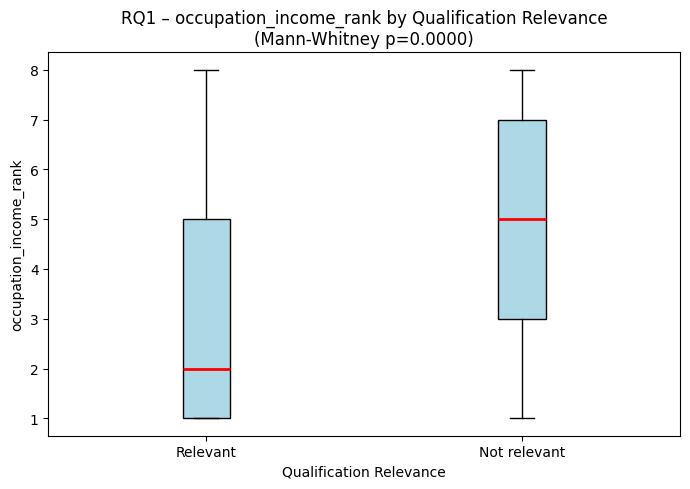

In [5]:
rq1_num = ["age_midpoint", "occupation_median_income_2022_23", "occupation_income_rank"]
# For each numerical feature, perform Mann-Whitney U test between the two target groups and visualize with boxplots
for col in rq1_num:
    grps = [rq1.loc[rq1["target"] == lbl, col].dropna().values for lbl in rq1["target"].unique()]
    lbls = list(rq1["target"].unique())
    stat, p = mannwhitneyu(grps[0], grps[1], alternative="two-sided")
    print(f"{col}  U={stat:.0f}, p={p:.4f}")

    plt.figure(figsize=(7, 5))
    plt.boxplot(grps, tick_labels=lbls, patch_artist=True,
                boxprops=dict(facecolor="lightblue"),
                medianprops=dict(color="red", linewidth=2))
    plt.title(f"RQ1 – {col} by Qualification Relevance\n(Mann-Whitney p={p:.4f})")
    plt.xlabel("Qualification Relevance")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"rq1_{col}_boxplot.png", dpi=150)
    plt.show()


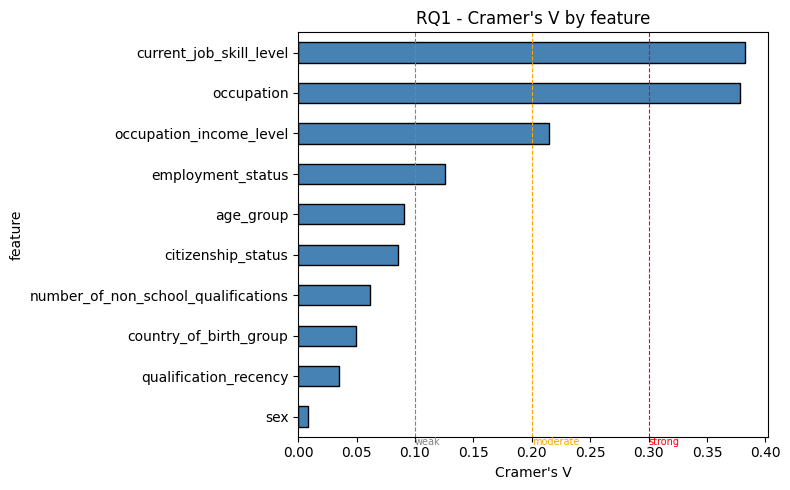

In [6]:
# Cramer's V summary – RQ1
cv1 = rq1_chi.sort_values("cramers_v").set_index("feature")["cramers_v"]
# Visualize Cramer's V values for each feature with reference lines for strength interpretation
plt.figure(figsize=(8, 5))
cv1.plot(kind="barh", color="steelblue", edgecolor="black")
for x, label, colour in [(0.10, "weak", "grey"), (0.20, "moderate", "orange"), (0.30, "strong", "red")]:
    plt.axvline(x, color=colour, linestyle="--", linewidth=0.8)
    plt.text(x, -0.7, label, fontsize=7, color=colour)
plt.title("RQ1 - Cramer's V by feature")
plt.xlabel("Cramer's V")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rq1_cramers_v.png", dpi=150)
plt.show()



RQ2 target counts:
 income_target
Below median income    142
Above median income    142
Name: count, dtype: int64


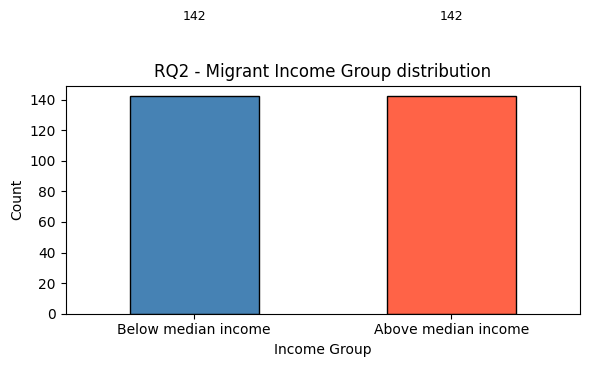

In [7]:
# Research Question 2: Migrant Income Group

counts2 = rq2["income_target"].value_counts()
print("\nRQ2 target counts:\n", counts2)
# Visualize the distribution of the target variable
plt.figure(figsize=(6, 4))
counts2.plot(kind="bar", color=["steelblue", "tomato"], edgecolor="black")
plt.title("RQ2 - Migrant Income Group distribution")
plt.xlabel("Income Group")
plt.ylabel("Count")
plt.xticks(rotation=0)
for i, v in enumerate(counts2.values):
    plt.text(i, v + 50, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rq2_target_distribution.png", dpi=150)
plt.show()



RQ2 chi-square / Cramer's V:


,feature,target,chi2,p_value,df,n,cramers_v,strength
0,age_range,income_target,86.59,0.0000,5,284,0.5522,strong
1,visa_group,income_target,60.62,0.0000,3,284,0.4620,strong
2,arrival_group,income_target,14.40,0.0007,2,284,0.2252,moderate
3,sex,income_target,10.27,0.0014,1,284,0.1901,weak–moderate
4,applicant_status,income_target,1.14,0.2855,1,284,0.0634,very weak



visa_group: chi2=60.62, p=0.0, V=0.462


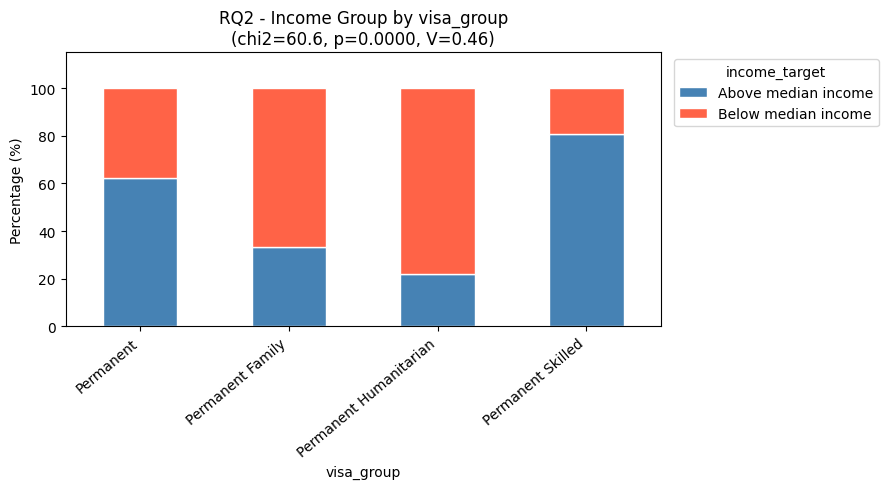


age_range: chi2=86.59, p=0.0, V=0.5522


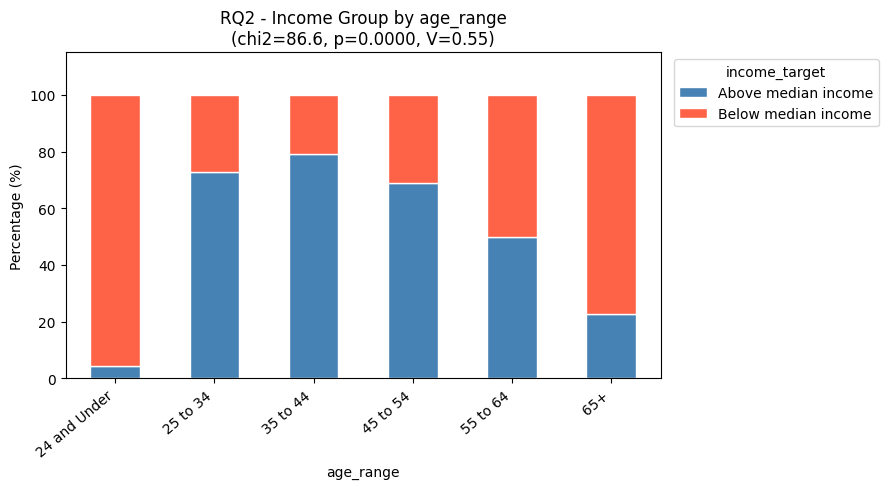


applicant_status: chi2=1.14, p=0.2855, V=0.0634


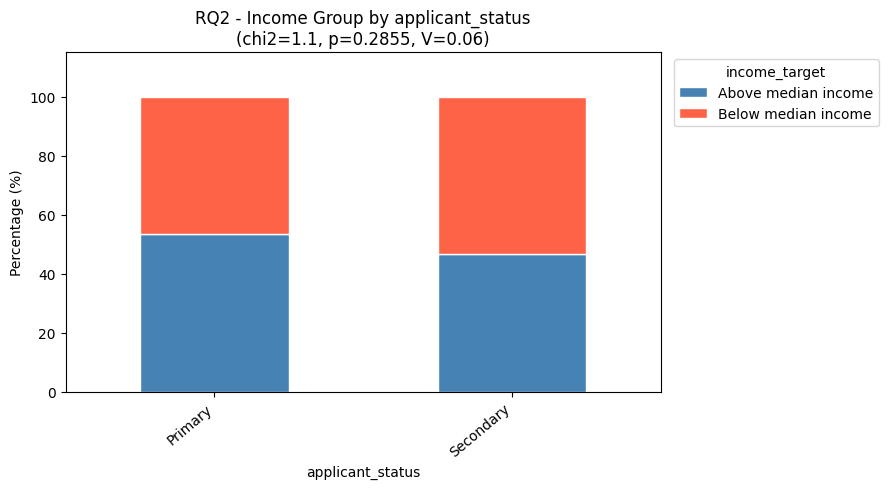


sex: chi2=10.27, p=0.0014, V=0.1901


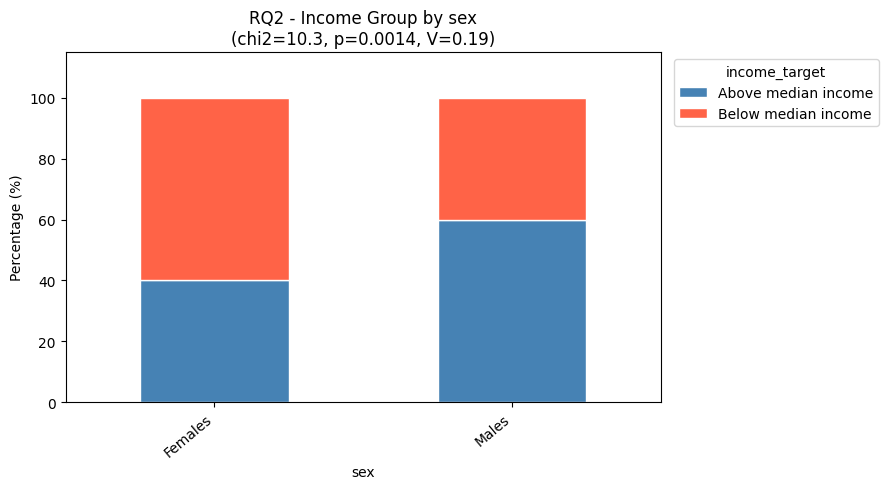


arrival_group: chi2=14.4, p=0.0007, V=0.2252


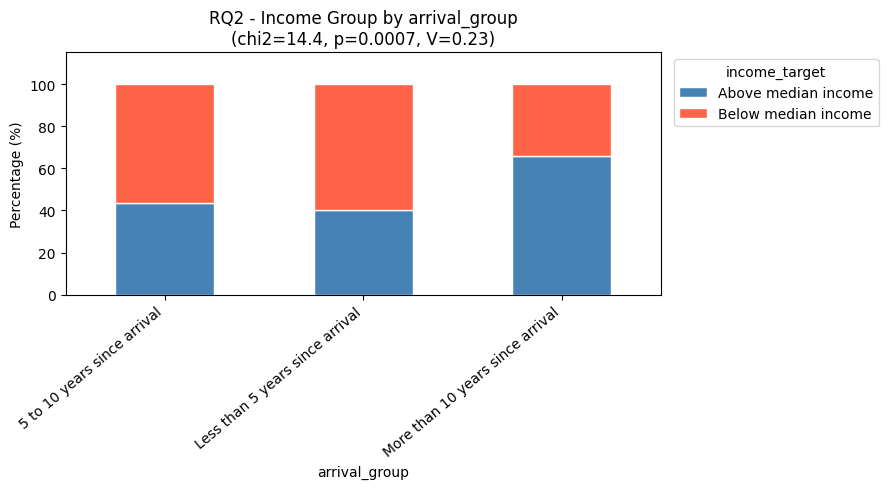


age_midpoint  U=9770, p=0.6480


C:\Users\ASUS\AppData\Local\Temp\ipykernel_27084\1327050581.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grps2, labels=lbls2, patch_artist=True,


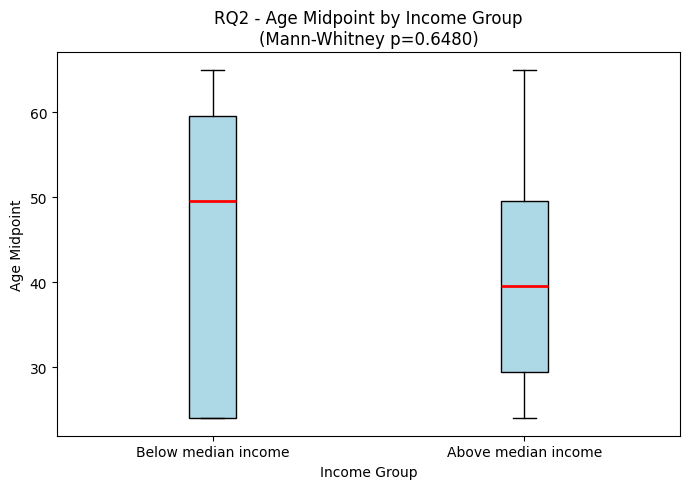

In [8]:
rq2_cat = ["visa_group", "age_range", "applicant_status", "sex", "arrival_group"]
# Perform chi-squared tests and calculate Cramer's V for each categorical feature against the income_target variable, then visualize the results
rq2_chi = chi_cramers_table(rq2, rq2_cat, "income_target")
print("\nRQ2 chi-square / Cramer's V:")
display(rq2_chi)
rq2_chi.to_csv(OUTPUT_DIR / "rq2_chi_square_cramers_v_results.csv", index=False)

for feat in rq2_cat:
    ct_pct = pd.crosstab(rq2[feat], rq2["income_target"])
    ct_pct = ct_pct.div(ct_pct.sum(axis=1), axis=0) * 100

    r = rq2_chi.loc[rq2_chi["feature"] == feat].iloc[0]
    print(f"\n{feat}: chi2={r.chi2}, p={r.p_value}, V={r.cramers_v}")

    ct_pct.plot(kind="bar", stacked=True, figsize=(9, 5),
                color=["steelblue", "tomato"], edgecolor="white")
    plt.title(f"RQ2 - Income Group by {feat}\n(chi2={r.chi2:.1f}, p={r.p_value:.4f}, V={r.cramers_v:.2f})")
    plt.xlabel(feat)
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=40, ha="right")
    plt.ylim(0, 115)
    plt.legend(title="income_target", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"rq2_{feat}_stacked.png", dpi=150)
    plt.show()

# For the age_midpoint numerical feature, perform Mann-Whitney U test between the two income groups and visualize with boxplots
grps2 = [rq2.loc[rq2["income_target"] == lbl, "age_midpoint"].dropna().values for lbl in rq2["income_target"].unique()]
lbls2 = list(rq2["income_target"].unique())
stat2, p2 = mannwhitneyu(grps2[0], grps2[1], alternative="two-sided")
print(f"\nage_midpoint  U={stat2:.0f}, p={p2:.4f}")

plt.figure(figsize=(7, 5))
plt.boxplot(grps2, labels=lbls2, patch_artist=True,
            boxprops=dict(facecolor="lightblue"),
            medianprops=dict(color="red", linewidth=2))
plt.title(f"RQ2 - Age Midpoint by Income Group\n(Mann-Whitney p={p2:.4f})")
plt.xlabel("Income Group")
plt.ylabel("Age Midpoint")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rq2_age_midpoint_boxplot.png", dpi=150)
plt.show()


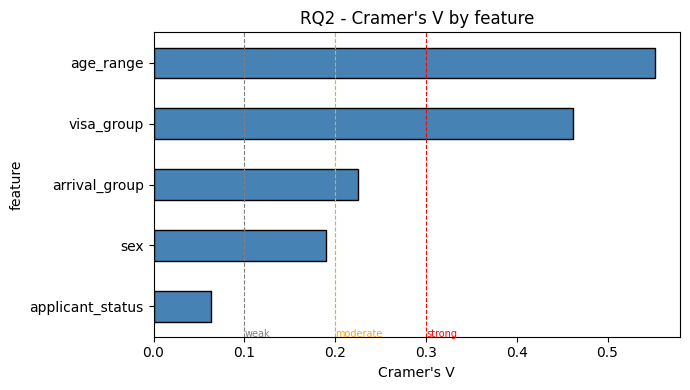

In [9]:
# Cramer's V Summary for Research Question 2
cv2 = rq2_chi.sort_values("cramers_v").set_index("feature")["cramers_v"]
# Visualize Cramer's V values for each feature with reference lines for strength interpretation
plt.figure(figsize=(7, 4))
cv2.plot(kind="barh", color="steelblue", edgecolor="black")
for x, label, colour in [(0.10, "weak", "grey"), (0.20, "moderate", "orange"), (0.30, "strong", "red")]:
    plt.axvline(x, color=colour, linestyle="--", linewidth=0.8)
    plt.text(x, -0.5, label, fontsize=7, color=colour)
plt.title("RQ2 - Cramer's V by feature")
plt.xlabel("Cramer's V")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rq2_cramers_v.png", dpi=150)
plt.show()
